<center><span style="color:#27A3F5;font-size:26px;font-weight:700">Rent price prediction in Berlin</span></center>

<span style="color:#609926;font-size:20px;font-weight:500">Modeling and predictions</span>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('../datasets/rent_listings_final.csv')
df.shape

(15601, 22)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15601 entries, 0 to 15600
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   listing_url           15601 non-null  object 
 1   cold_rent             15601 non-null  float64
 2   area                  15601 non-null  float64
 3   rooms                 15601 non-null  float64
 4   floor                 13659 non-null  float64
 5   free_from             15601 non-null  object 
 6   has_balkon            15601 non-null  bool   
 7   has_terrasse          15601 non-null  bool   
 8   has_garten            15601 non-null  bool   
 9   elevator              15601 non-null  bool   
 10  parking               15601 non-null  bool   
 11  has_basement          15601 non-null  bool   
 12  is_barrier-free       15601 non-null  bool   
 13  has_built-in_kitchen  15601 non-null  bool   
 14  has_bathtub           15601 non-null  bool   
 15  has_shower         

In [4]:
# So we get reproducable results:
np.random.seed(16)

<span style="color:#42b0f5;font-size:18px;font-weight:500">Part 1: Feature Engineering</span>

<span style="font-weight:500">
1. Split the dataset into a train set (80%) and a test set (20%).
</span>

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["cold_rent", "listing_url"])
y = df["cold_rent"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

<span style="font-weight:500">
2. Setting up the pipeline - with a scaler, inputer and One-Hot Encoder
</span>

In [6]:
numeric_cols     = ["area", "rooms"]
floor_col        = ["floor"]
year_col         = ["year_built"]
bool_cols        = [
    "has_balkon", "has_terrasse", "has_garten",
    "elevator", "parking", "has_basement",
    "is_barrier-free", "has_built-in_kitchen",
    "has_bathtub", "has_shower"
]
categorical_cols = [
    "district", "energy_source", "heating_type",
    "flooring_type", "property_condition", "free_from"
]

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("floor", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), floor_col),
        ("year", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), year_col),
        ("bool", "passthrough", bool_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)

<span style="color:#42b0f5;font-size:18px;font-weight:500">Part 2: Modeling and model evaluation</span>

<span style="font-weight:500">
1. Modeling and training
</span>

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)
print("Features after preprocessing:", len(pipeline.named_steps["preprocessor"].get_feature_names_out()))

Features after preprocessing: 99


<span style="font-weight:500">
99 features for 15601 samples are not too many features.
</span>

In [9]:
rmse_scores = cross_val_score(pipeline, X_train, y_train, scoring="neg_mean_squared_error", cv=10)
mae_scores = cross_val_score(pipeline, X_train, y_train, scoring="neg_mean_absolute_error", cv=10)
r2_scores = cross_val_score(pipeline, X_train, y_train, scoring="r2", cv=10)

print("RMSE:", np.sqrt(-rmse_scores.mean()))
print("MAE:", -mae_scores.mean())
print("R2:", r2_scores.mean())

RMSE: 431.52294225249784
MAE: 291.2532124031585
R2: 0.6586293404895676


<span style="font-weight:500">
Linear regression performed with an R score of 0.658 which is not very good, but we cannot expect a simple model to capture all the trends with such a huge dataset. </span>

In [11]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("model", Ridge())
])

param_grid = {
    "poly__degree": [1, 2],
    "model__alpha": [0.01, 0.1, 1.0, 10.0]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("CV RMSE:", np.sqrt(-grid.best_score_))

y_pred = best_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)

print("Test RMSE:", test_rmse)
print("Test R2:", test_r2)
print("Test MAE:", test_mae)

Best parameters: {'model__alpha': 10.0, 'poly__degree': 2}
CV RMSE: 303.0696426512638
Test RMSE: 278.07515825124705
Test R2: 0.8566074226883237
Test MAE: 192.55706296692375


<span style="font-weight:500">
A polynomial of 2nd degree performs better, much better, than the linear model, but with an R-squared of 0.8566 this is definitely far from the best model we could use. </span>

In [12]:
from sklearn.neighbors import KNeighborsRegressor

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor(algorithm="ball_tree"))
])

param_grid = {
    "model__n_neighbors": [3, 5],
    "model__weights": ["distance"],
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("CV RMSE:", np.sqrt(-grid.best_score_))

y_pred = best_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)

print("Test RMSE:", test_rmse)
print("Test R2:", test_r2)
print("Test MAE:", test_mae)

Best parameters: {'model__n_neighbors': 3, 'model__weights': 'distance'}
CV RMSE: 295.33624717435515
Test RMSE: 272.4335986633202
Test R2: 0.8623666695717909
Test MAE: 153.15027400251515


<span style="font-weight:500">
KNN performs slightly better, but not good enough to be considered our final model. </span>

In [13]:
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVR())
])

param_grid_svr = [
    {"model__kernel": ["linear"], "model__C": [0.1, 1, 10]},
    {"model__kernel": ["rbf"], "model__C": [1, 10, 100], "model__gamma": ["scale", "auto"]},
    {"model__kernel": ["poly"], "model__C": [1, 10], "model__gamma": ["scale"], "model__degree": [2, 3]},
]

grid = RandomizedSearchCV(
    pipeline,
    param_grid_svr,
    n_iter=10,  # we only try 10 random combos instead of all
    cv=4,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("CV RMSE:", np.sqrt(-grid.best_score_))

y_pred = best_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)

print("Test RMSE:", test_rmse)
print("Test R2:", test_r2)
print("Test MAE:", test_mae)

Best parameters: {'model__kernel': 'rbf', 'model__gamma': 'auto', 'model__C': 100}
CV RMSE: 429.96171026349384
Test RMSE: 401.47468569172395
Test R2: 0.7011050219579555
Test MAE: 253.17133330602036


<span style="font-weight:500">
SVR performs very poorly in this dataset </span>

In [14]:
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor())
])

param_grid_rf = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__max_depth": [None, 10, 20, 30, 40],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2"],
}

grid = GridSearchCV(
    pipeline,
    param_grid_rf,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("CV RMSE:", np.sqrt(-grid.best_score_))

y_pred = best_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)

print("Test RMSE:", test_rmse)
print("Test R2:", test_r2)
print("Test MAE:", test_mae)

Best parameters: {'model__max_depth': 40, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
CV RMSE: 232.7645719745032
Test RMSE: 216.61081224313432
Test R2: 0.9129913267478801
Test MAE: 126.1313652233365


<span style="font-weight:500">
We got a good R squared of 0.913 and lower errors. This is the best model so far. We should aim for a higher R-squared. </span>

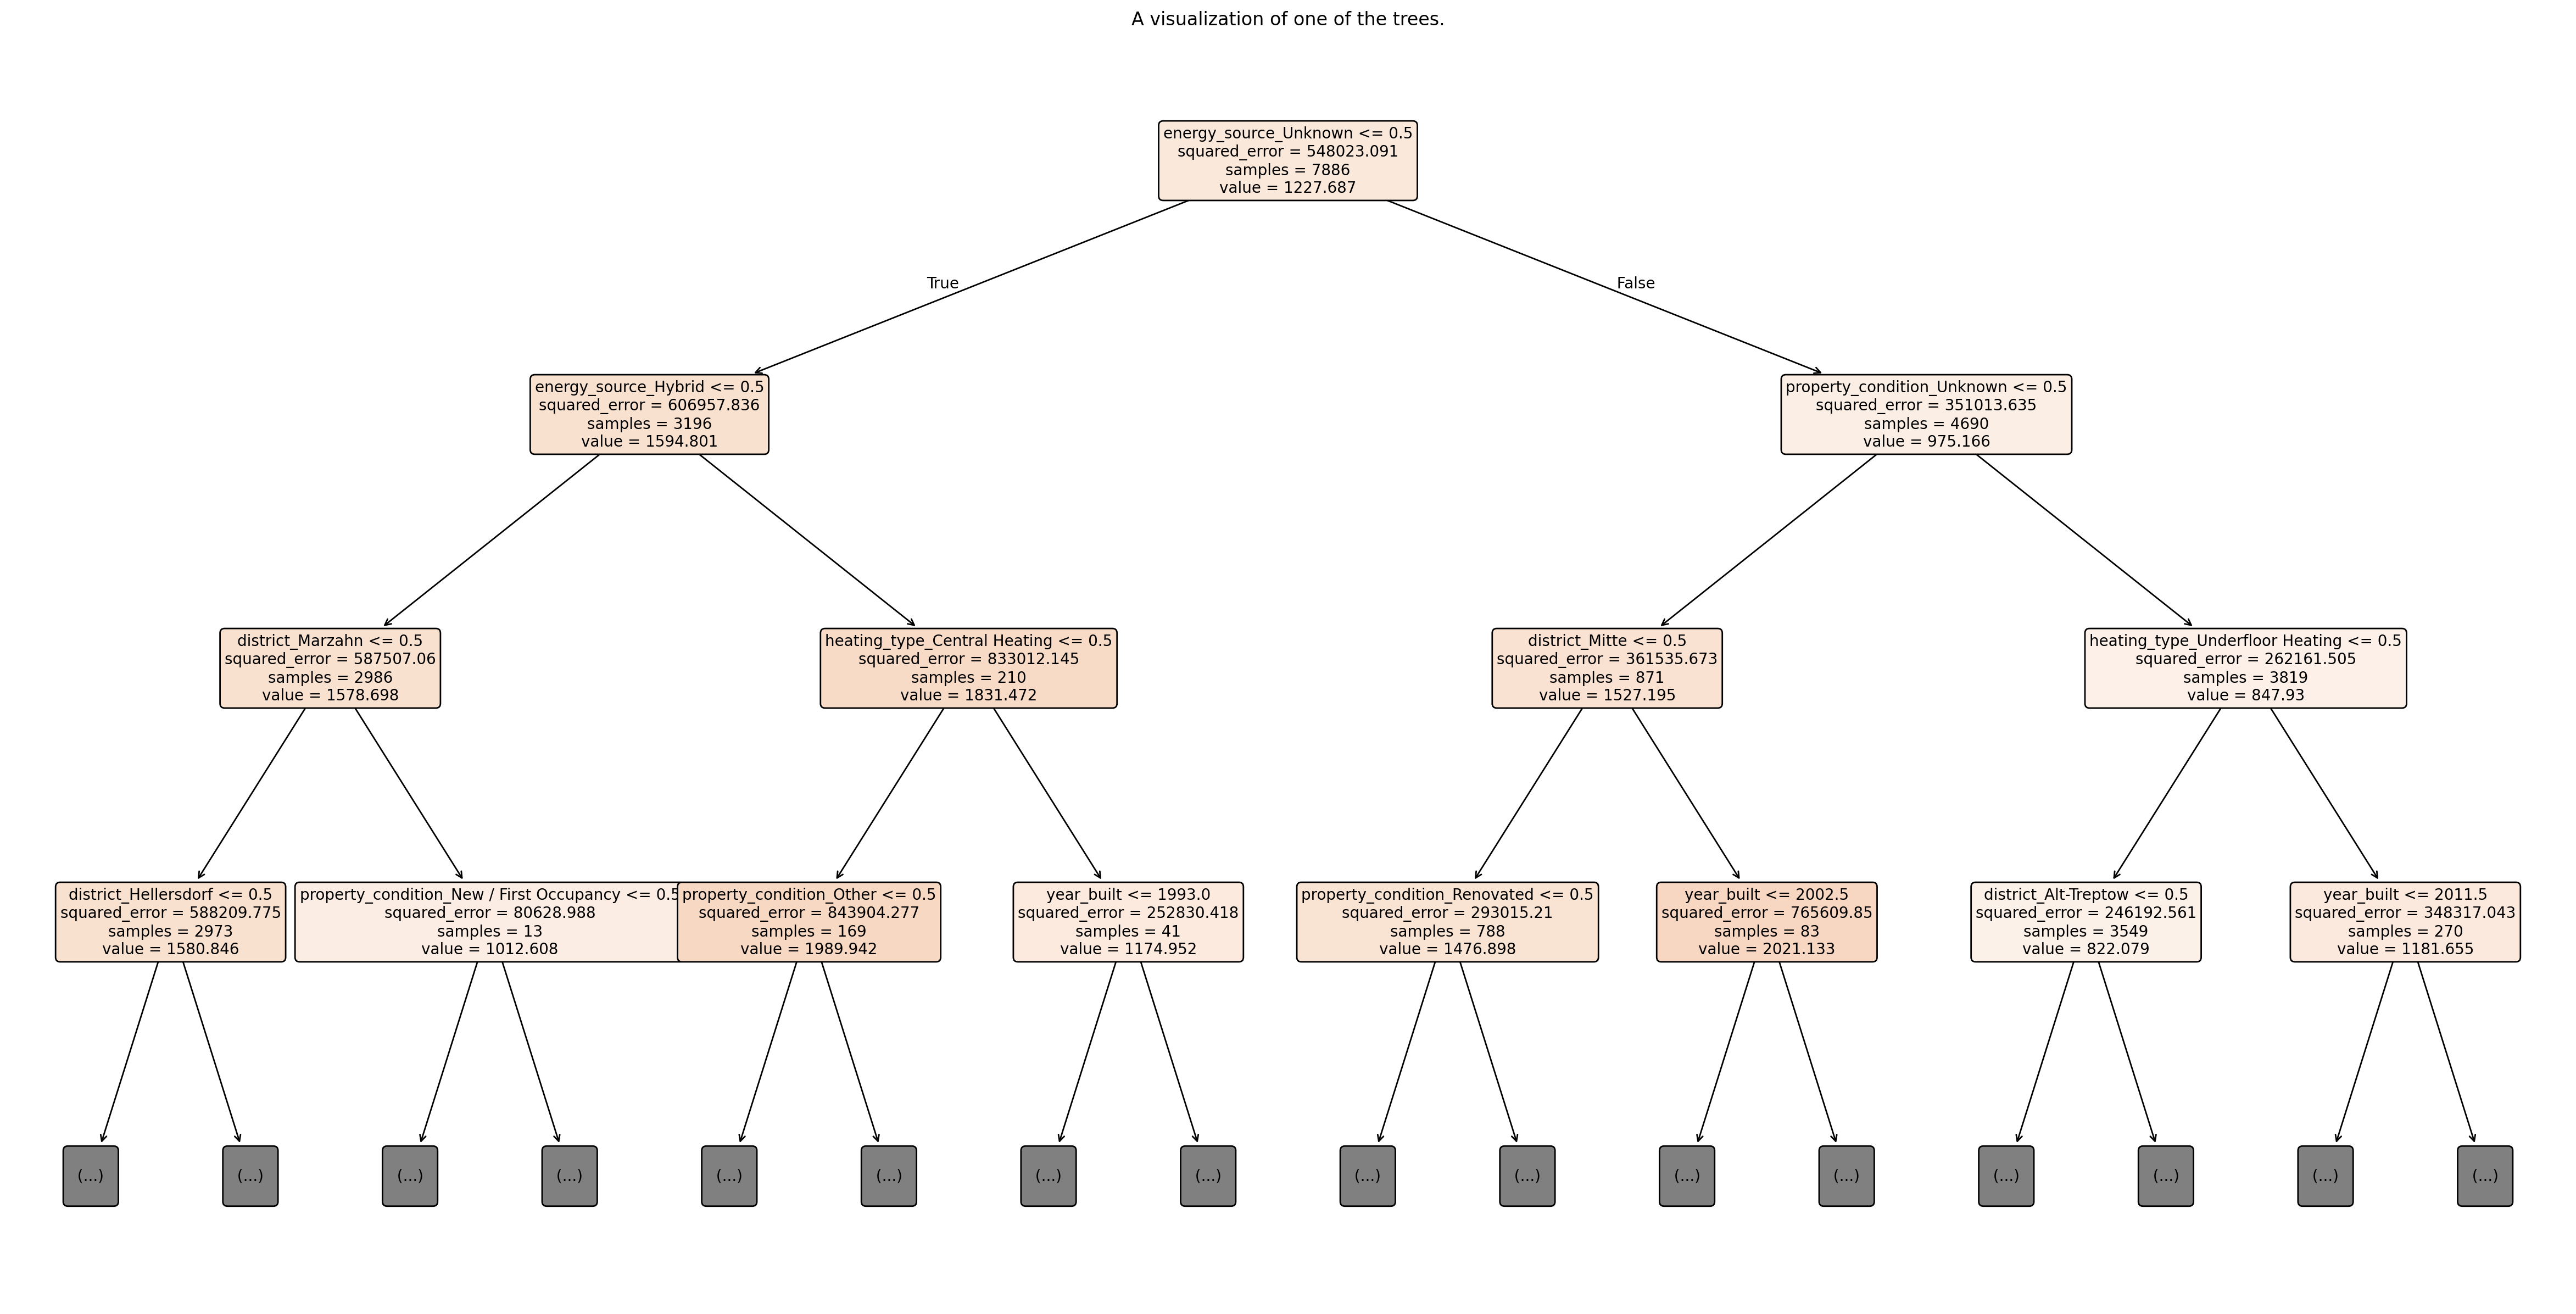

In [23]:
from sklearn.tree import export_graphviz, plot_tree
import matplotlib.pyplot as plt

feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
feature_names = [f.split("__")[1] for f in feature_names]

plt.figure(figsize=(30, 15), dpi=200)

plot_tree(
    best_model.named_steps["model"].estimators_[16],
    filled=True,
    max_depth=3,
    feature_names=feature_names,
    rounded=True,
    fontsize=10 
)
plt.title("A visualization of one of the trees.")
plt.show()

<span style="font-weight:500">
While a couple of things might seem confusing, like values of thresholds for each split due to standardization or the name of the features used due to encoding, the interpretation of the image becomes unclear. The purpose of this visualization is just to create an idea of how the Random Forest is operating by selecting the best features from a random set of features for each split and computing the best thresholds to minimize the loss. </span>

                                     feature  importance
0                                       area    0.245463
1                                      rooms    0.127469
98                         free_from_unknown    0.055263
3                                 year_built    0.055249
94                property_condition_Unknown    0.044771
74                     energy_source_Unknown    0.044465
96                     free_from_immediately    0.040733
2                                      floor    0.021031
43                            district_Mitte    0.020254
77           heating_type_Underfloor Heating    0.018558
7                                   elevator    0.015433
13                                has_shower    0.014748
11                      has_built-in_kitchen    0.014284
8                                    parking    0.014254
67            energy_source_District Heating    0.013756
5                               has_terrasse    0.011796
89  property_condition_New / Fi

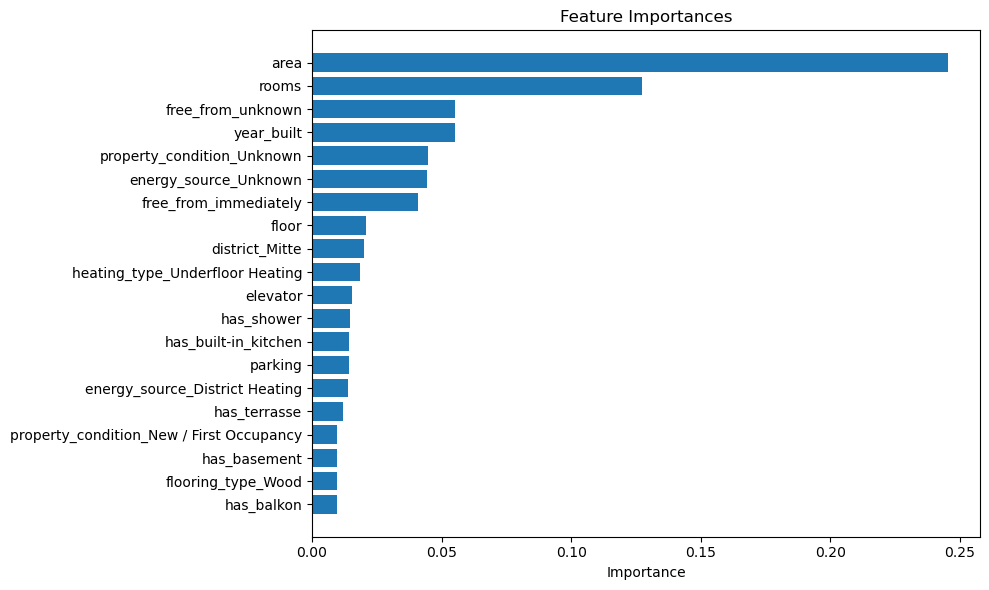

In [24]:
importances = best_model.named_steps["model"].feature_importances_

fi_df = pd.DataFrame({"feature": feature_names, "importance": importances})
fi_df = fi_df.sort_values("importance", ascending=False)

print(fi_df[:20])

plt.figure(figsize=(10, 6))
plt.barh(fi_df["feature"][:20], fi_df["importance"][:20])
plt.gca().invert_yaxis()
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

<span style="font-weight:500">
The graph shows the importance of the features. As we also noticed during Exploratory Data Analysis, the features with the highest importance correspond to the features we concluded had the highest impact, with area having a high importance of 25%, followed by the number of rooms and then the availability of the apartment. By observing this graph, we can gain additional information other than the one we discovered in EDA. For example, we have 'free_from_unknown' as our 3rd feature, with a very relatively high importance. 
<br>
What we notice here is that many unknown categories show up as the top 15 most important features. These could be due to the fact that some of them had high occurrences from 35% to 65% depending on the feature. During EDA we noticed that some of these categories had a really strong meaning and impact on the price, for example "free_from_unknown" making it to the top 3 here, was associated with a huge negative impact on the price.
<br>
One specific category, "Miete" being the 8th most important with 2.2% importance, shows cleaning and working with difficult features like location really pays off and can help with modeling for difficult problems. 
</span>

In [25]:
from xgboost import XGBRegressor

param_grid_xgb = {
    "model__n_estimators": [400, 600],
    "model__max_depth": [5, 7],
    "model__learning_rate": [0.001, 0.01, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 3],
    "model__gamma": [0, 0.1]
}

# Model A — With Imputation

pipeline_impute = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=42, objective="reg:squarederror"))
])

grid_impute = GridSearchCV(
    pipeline_impute,
    param_grid_xgb,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

grid_impute.fit(X_train, y_train)

best_model_impute = grid_impute.best_estimator_

print("Model A (XGBoost with imputation):")
print("Best params:", grid_impute.best_params_)
print("CV RMSE:", np.sqrt(-grid_impute.best_score_))

y_pred_impute = best_model_impute.predict(X_test)

print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_impute)))
print("Test R2:", r2_score(y_test, y_pred_impute))
print("Test MAE:", mean_absolute_error(y_test, y_pred_impute))

# Model B — Without Imputation (replace year and floor transformers with passthrough)
preprocessor_no_impute = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("floor", "passthrough", floor_col),
        ("year", "passthrough", year_col),
        ("bool", "passthrough", bool_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)

pipeline_no_impute = Pipeline([
    ("preprocessor", preprocessor_no_impute),
    ("model", XGBRegressor(random_state=42, objective="reg:squarederror"))
])

grid_no_impute = GridSearchCV(
    pipeline_no_impute,
    param_grid_xgb,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

grid_no_impute.fit(X_train, y_train)

best_model_no_impute = grid_no_impute.best_estimator_

print()
print("Model B (XGBoost without imputation):")
print("Best params:", grid_no_impute.best_params_)
print("CV RMSE:", np.sqrt(-grid_no_impute.best_score_))

y_pred_no_impute = best_model_no_impute.predict(X_test)

print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_no_impute)))
print("Test R2:", r2_score(y_test, y_pred_no_impute))
print("Test MAE:", mean_absolute_error(y_test, y_pred_no_impute))

Fitting 5 folds for each of 192 candidates, totalling 960 fits
Model A (XGBoost with imputation):
Best params: {'model__colsample_bytree': 0.8, 'model__gamma': 0, 'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__min_child_weight': 1, 'model__n_estimators': 600, 'model__subsample': 1.0}
CV RMSE: 211.6285410006643
Test RMSE: 197.71807325651665
Test R2: 0.9275071750524302
Test MAE: 113.90591449731437
Fitting 5 folds for each of 192 candidates, totalling 960 fits

Model B (XGBoost without imputation):
Best params: {'model__colsample_bytree': 1.0, 'model__gamma': 0.1, 'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__min_child_weight': 1, 'model__n_estimators': 600, 'model__subsample': 0.8}
CV RMSE: 212.57463590492188
Test RMSE: 198.03773243524705
Test R2: 0.9272725811290006
Test MAE: 109.67460555956939


<span style="font-weight:500">
XGB is one of the few models that can handle missing values, that is the reason why we tried 2 approaches, one with imputed missing values and one with missing values as they are. Both models perform nearly the same, with the model with imputed values being slightly better. Both of them have a really good performance with an R-squared of almost 0.93, which, considering our data set, is a very good and realistic performance.
<br>
Personally, I thought that XGBoost was going to be the best expected model and most likely this is the model we are going to deploy.
<br>
If you can notice, the hyperparameters of the best-performing model are the highest values, so I would prefer to do another grid search with other values, and in case we get a higher performance, we should also check for overfitting.
</span>

In [26]:
param_grid_xgb = {
    "model__n_estimators": [600, 800],
    "model__max_depth": [9, 11],
    "model__learning_rate": [0.1, 0.5],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 3],
    "model__gamma": [0, 0.1]
}

pipeline_impute = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=42, objective="reg:squarederror"))
])

grid_impute = GridSearchCV(
    pipeline_impute,
    param_grid_xgb,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

grid_impute.fit(X_train, y_train)

best_model_impute = grid_impute.best_estimator_

print("Model A (XGBoost with imputation):")
print("Best params:", grid_impute.best_params_)
print("CV RMSE:", np.sqrt(-grid_impute.best_score_))

y_pred_impute = best_model_impute.predict(X_test)

print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_impute)))
print("Test R2:", r2_score(y_test, y_pred_impute))
print("Test MAE:", mean_absolute_error(y_test, y_pred_impute))

Fitting 5 folds for each of 128 candidates, totalling 640 fits
Model A (XGBoost with imputation):
Best params: {'model__colsample_bytree': 0.8, 'model__gamma': 0, 'model__learning_rate': 0.1, 'model__max_depth': 9, 'model__min_child_weight': 1, 'model__n_estimators': 600, 'model__subsample': 1.0}
CV RMSE: 210.4017880226035
Test RMSE: 191.86864469509842
Test R2: 0.9317330813998724
Test MAE: 98.89716362001955


<span style="font-weight:500">
We notice a slight improvement by finding similar combinations of hyperparameters. Looking for another combination of hyperparameters is pointless since we ended up with almost the same hyperparameters and the improvement is small.
</span>

In [27]:
y_pred_impute_train = best_model_impute.predict(X_train)

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_impute_train)))
print("Train R2:", r2_score(y_train, y_pred_impute_train))
print("Train MAE:", mean_absolute_error(y_train, y_pred_impute_train))

Train RMSE: 69.94283069592002
Train R2: 0.9910362437624479
Train MAE: 35.5505829901573


<span style="font-weight:500">
If we compare them with the training performance metrics, we notice a difference of R squared of 0.06, which is not small, we are undeniably overfitting and considering XGBoost as an advanced model, overfitting is not uncommon. Considering the difference, the overfitting is not moderate to low and also considering our huge dataset, this level of overfitting is justifiable.
<br>
Let's also run a RepeatedKFold to check stability, if the model is stable, we shouldn't worry.
</span>

In [28]:
from sklearn.model_selection import RepeatedKFold, cross_val_score

best_model = best_model_impute

rkf = RepeatedKFold(
    n_splits=5,     
    n_repeats=3,     
    random_state=16
)

scores = cross_val_score(
    best_model, 
    X_train, 
    y_train,
    scoring='neg_root_mean_squared_error',
    cv=rkf,
    n_jobs=-1
)

rmse_scores = -scores  # make positive

print("Mean RMSE:", np.mean(rmse_scores))
print("Std RMSE:", np.std(rmse_scores))

Mean RMSE: 207.71979202285073
Std RMSE: 13.737900869906625


<span style="font-weight:500">
We have a standard deviation of 13.73, which is not the best we could get (something below 10 is excellent), but it is also not bad (something above 20). Normally, I would say we are in a gray area, but considering our huge and real dataset, such a score is totally realistic and acceptable.
</span>

In [30]:
y_stability_test = np.array(y_test)

# Create dataframe for grouping
df_last_test = pd.DataFrame({
    "y_true": y_stability_test
})

# Quantile boundaries
low_q = np.quantile(y_test, 0.33)
high_q = np.quantile(y_test, 0.66)

def assign_group(value):
    if value <= low_q:
        return "Low"
    elif value <= high_q:
        return "Medium"
    else:
        return "High"

df_last_test["group"] = df_last_test["y_true"].apply(assign_group)

y_pred = best_model.predict(X_test)

df_last_test["y_pred"] = y_pred

group_results = {}

for group_name in ["Low", "Medium", "High"]:
    mask = df_last_test["group"] == group_name
    
    rmse = np.sqrt(
        mean_squared_error(
            df_last_test.loc[mask, "y_true"],
            df_last_test.loc[mask, "y_pred"]
        )
    )
    
    group_results[group_name] = rmse

print("RMSE by target region:")
for k, v in group_results.items():
    print(f"{k}: {v:.3f}")

RMSE by target region:
Low: 172.208
Medium: 172.945
High: 224.740


<span style="font-weight:500">
The model performs well across low and medium target value regions, with a much higher error in the high-value tail due to data skewness and fewer extreme observations. The model can be considered robust and suitable for prediction purposes. I would say it is a very decent model.
The only future improvements that could be considered include enhancing the accuracy in high-value samples, but that would be the case only if tail prediction were very important for the application and this is not the case.
</span>

In [36]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

def build_nn(input_dim):

    model = models.Sequential()

    model.add(layers.Input(shape=(input_dim,)))

    model.add(layers.Dense(256, activation='relu',
             kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.2))

    model.add(layers.Dense(128, activation='relu',
             kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.2))

    model.add(layers.Dense(64, activation='relu',
             kernel_regularizer=tf.keras.regularizers.l2(0.001)))

    model.add(layers.Dense(32, activation='relu',
             kernel_regularizer=tf.keras.regularizers.l2(0.001)))

    model.add(layers.Dense(1))  # regression output

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate = 0.0005),
        loss='mse',
        metrics=[tf.keras.metrics.RootMeanSquaredError()]
    )

    return model

In [37]:
nn_pipeline = Pipeline([
        ("preprocessor", preprocessor),
])

X_train_processed = nn_pipeline.fit_transform(X_train)

X_test_processed = nn_pipeline.transform(X_test)
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

nn_model = build_nn(X_train_processed.shape[1])

history = nn_model.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/300
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 1841865.0000 - root_mean_squared_error: 1357.1532 - val_loss: 1588984.6250 - val_root_mean_squared_error: 1260.5492
Epoch 2/300
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 533653.0000 - root_mean_squared_error: 730.5152 - val_loss: 298126.6562 - val_root_mean_squared_error: 546.0091
Epoch 3/300
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 227134.0469 - root_mean_squared_error: 476.5849 - val_loss: 214889.2344 - val_root_mean_squared_error: 463.5606
Epoch 4/300
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 191040.3125 - root_mean_squared_error: 437.0808 - val_loss: 161459.1094 - val_root_mean_squared_error: 401.8188
Epoch 5/300
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 157439.7344 - root_mean_squared_error: 396.7858 - val_loss: 126699.3203 - val_root_mean_squared_error: 355.9474
Epoch 6/300
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 133126.0312 - root_mean_squared_error: 364.8633 - val_loss: 108272.656

In [38]:
y_pred_nn = nn_model.predict(X_test_processed).flatten()

rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn = r2_score(y_test, y_pred_nn)

print("NN RMSE:", rmse_nn)
print("NN R2:", r2_nn)

98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step   
NN RMSE: 221.49237793646634
NN R2: 0.9090254625520644


<span style="font-weight:500">
The Neural Network that we modeled performs better than most of the models, but still it doesn't achieve the results of XGBoost. During training we notice that it converges around 180 epochs, so we cannot improve it further unless we model a better NN. 
</span>

In [39]:
y_pred_nn = nn_model.predict(X_train_processed).flatten()

rmse_nn = np.sqrt(mean_squared_error(y_train, y_pred_nn))
r2_nn = r2_score(y_train, y_pred_nn)

print("NN RMSE:", rmse_nn)
print("NN R2:", r2_nn)

390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
NN RMSE: 171.54163003153985
NN R2: 0.9460808927380162


<span style="font-weight:500">
Similar to XGBoost it has a moderate to low level of overfitting, so it doesn't have any advantages over XGBoost.
</span>

<span style="color:#42b0f5;font-size:18px;font-weight:500">Part 3: Modeling interpretation and model deployment</span>

In [40]:
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('floor', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

In [44]:
import shap

model = best_model.named_steps["model"]
X_test_processed = best_model.named_steps["preprocessor"].transform(X_test)

explainer = shap.Explainer(model)
shap_values = explainer(X_test_processed)

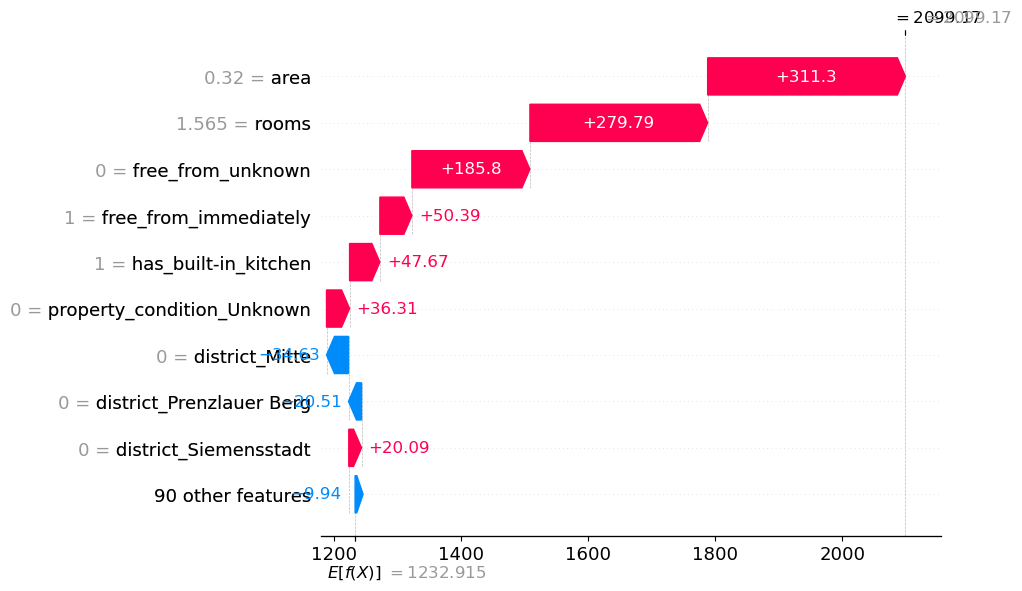

In [45]:
explanation = shap.Explanation(
    values=shap_values.values,
    base_values=shap_values.base_values,
    data=X_test_processed,
    feature_names=feature_names
)

shap.plots.waterfall(explanation[0])

<span style="font-weight:500">
We start with the expected value of the model’s predictions, which is €1232.915. This represents the average predicted rent across all observations, before taking into consideration specific features of a particular apartment.
<br>
Each feature then contributes to shifting this baseline up or down. The feature with the strongest positive contribution is area, which increases the predicted rent by €311.3. The second most influential feature is the number of rooms, which increases the prediction by €279.79.
<br>
After adding all positive feature contributions, the predicted rent increases to €2099.17. Negative feature contributions then reduce this value to approximately €1150.
<br> 
The feature with the strongest negative contribution is the category “Mitte”, which decreases the predicted rent by €34.63.
<br>
This ranking has a high similarity with the feature's importance ranking we displayed above. 
</span>

In [46]:
importances = model.feature_importances_

fi_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
)

print(fi_df.head(10))

                            feature  importance
98                free_from_unknown    0.216024
74            energy_source_Unknown    0.048011
43                   district_Mitte    0.043445
1                             rooms    0.034761
90  property_condition_Old Building    0.033687
55                 district_Spandau    0.024431
53              district_Schöneberg    0.022718
24               district_Friedenau    0.022481
94       property_condition_Unknown    0.022111
54            district_Siemensstadt    0.021097


<span style="font-weight:500">
The importance ranking for our final model does not correspond, which should be expected because they tell us what reduces error, and their role is not for economic interpretation. That is the role of SHAP values, they tell us what moves the predictions.
</span>

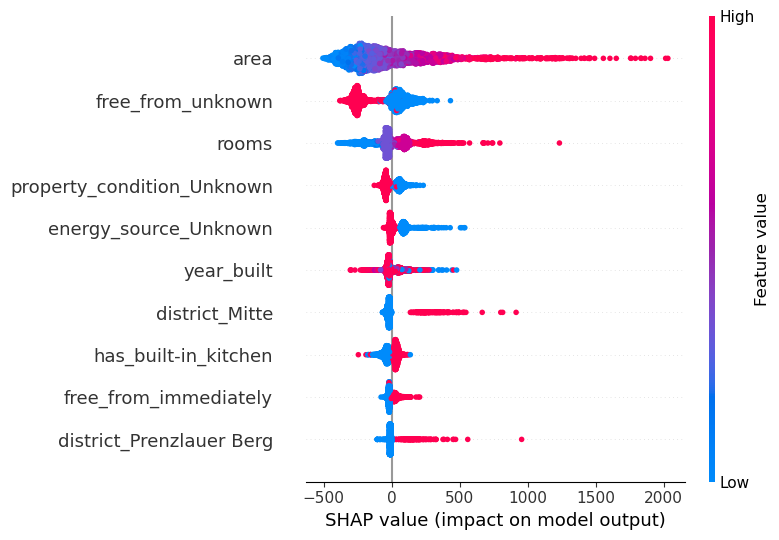

In [47]:
import warnings
warnings.filterwarnings("ignore")
shap.summary_plot(explanation, max_display=10)

<span style="font-weight:500">
This graph is extremely informative and easy to interpret. It shows us which features impact the prices the most and their impact.
<br> 
Features like area and number of rooms are continuous features with a positive contribution, meaning the more we increase them, the more the price increases. 
<br>
Features like free_from_unknown, property_condition_unknown and energy_source_unknown are categorical features that have a positive impact when equal to 1 and lower the prices when they are equal to 0, so when they are not present.
<br>
Year_built is a continuous feature with an inverse effect, meaning with the increase of the feature value, the prices tend to lower, that would mean the older ones tend to have lower prices. In this case, the effect is not very strong and clear but still visible.
<br> 
Categorical features like "district_Mitte", "has_built-in_kitchen", "heating_type_Underfloor Heating" and "has_shower" are features with a positive impact, meaning if present, the price is higher.
</span>

<span style="font-weight:500">
Save our XGBoost model for deployment
</span>

In [48]:
import joblib

joblib.dump(best_model, "best_model.pkl")

['best_model.pkl']

<span style="font-weight:500">
Load the model.
</span>

In [49]:
model = joblib.load("best_model.pkl")

In [50]:
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('floor', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

<span style="font-weight:500">
Test a prediction using unseen data, simulating how a user would interact with the model in production.

We evaluated a new rental listing posted on 03/03/2026 with the following characteristics:

Cold rent: 1,990 euro

Apartment size: 83.3 m²

Number of rooms: 4

Floor: 1st floor

Availability: immediately

District: Friedrichsfelde, Berlin

Amenities: built-in kitchen, bathtub, and shower

Construction year: 2025

Additional features: a balcony, terrace, garden, parking, and basement were absent, while an elevator and barrier-free access were available.
</span>

In [63]:
raw_listing = {
    "area": 83.3,
    "rooms": 4,
    "floor": 1,
    "free_from": "immediately",
    "has_balkon": True,
    "has_terrasse": False,
    "has_garten": False,
    "elevator": True,
    "parking": False,
    "has_basement": False,
    "is_barrier-free": True,
    "has_built-in_kitchen": True,
    "has_bathtub": True,
    "has_shower": True,
    "flooring_type": "Underfloor Heating",
    "energy_source": "Other",
    "heating_type": "Central Heating",
    "property_condition": "New / First Occupancy",
    "year_built": 2025,
    "district": "Friedrichsfelde"
}

new_data = pd.DataFrame([raw_listing])
prediction = model.predict(new_data)
print("Prediction:", prediction[0])

Prediction: 1870.1433


<span style="font-weight:500">
We got an excellent prediction, very close to the original value (1990 euro).
</span>

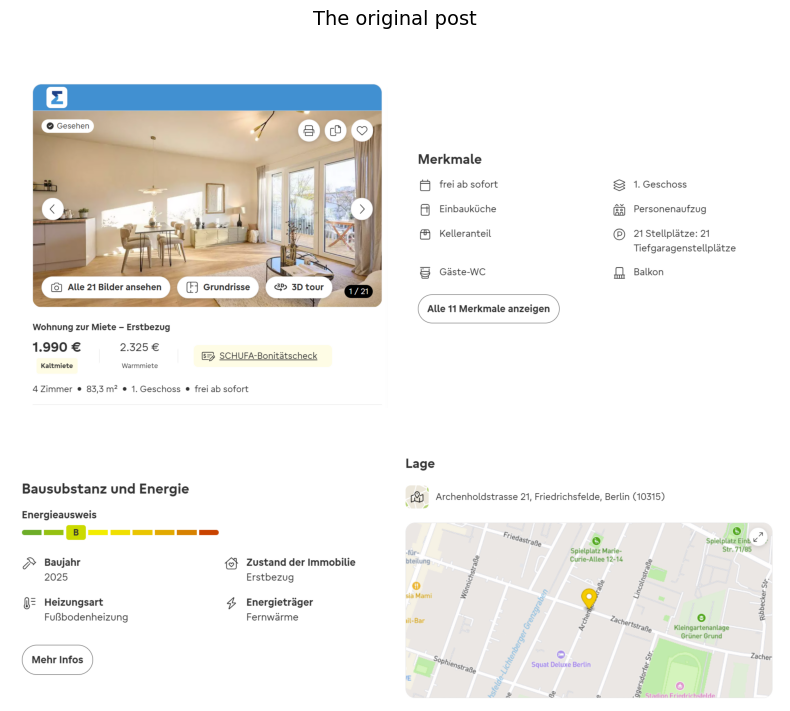

In [65]:
from PIL import Image

images = ["../images/1.png", "../images/2.png", "../images/3.png", "../images/4.png"]

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for ax, img_path in zip(axes.flatten(), images):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")

fig.suptitle("The original post", fontsize=14)

plt.tight_layout()
plt.show()